

# 🛒 E-commerce Data Analysis Project

## 🎯 Objective
The goal of this project is to analyze e-commerce data to understand sales performance, customer behavior, and revenue trends.


In [33]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt



# Load datasets
payments = pd.read_csv("olist_order_payments_dataset.csv")
orders = pd.read_csv("olist_orders_dataset.csv")

# Merge data
df = pd.merge(orders, payments, on="order_id")

## 📦 Order Status vs Revenue
This analysis shows how order status impacts revenue generation.
Delivered orders contribute the most revenue.

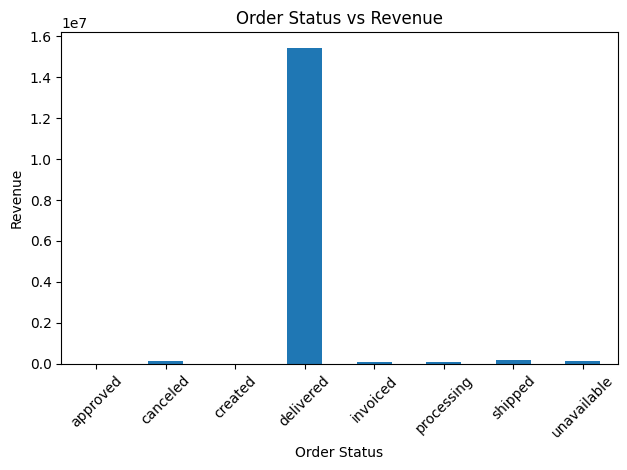

In [34]:
status_revenue = df.groupby("order_status")["payment_value"].sum()

status_revenue.plot(kind="bar")

plt.title("Order Status vs Revenue")
plt.xlabel("Order Status")
plt.ylabel("Revenue")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

💡 Key Business Insight:
Delivered orders generate the highest revenue. Cancelled and unavailable orders contribute very little since transactions are not completed.

## 🌆 Top 5 Cities by Revenue
Identify which cities generate the highest revenue.

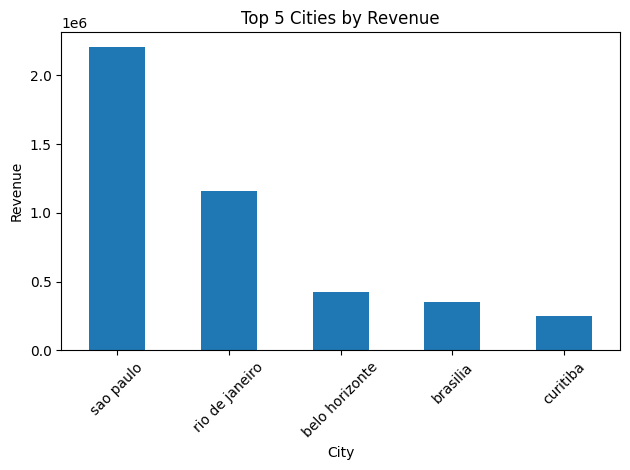

In [35]:
customers = pd.read_csv("olist_customers_dataset.csv")
df = pd.merge(df, customers, on="customer_id")

top_cities = df.groupby("customer_city")["payment_value"].sum().sort_values(ascending=False).head(5)

top_cities.plot(kind="bar")

plt.title("Top 5 Cities by Revenue")
plt.xlabel("City")
plt.ylabel("Revenue")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

💡 Key Business Insight:
Top cities contribute a major portion of total revenue. Businesses should focus more on these high-performing cities to maximize profits.

## 📅 Monthly Revenue Trend
Analyze how revenue changes over time.

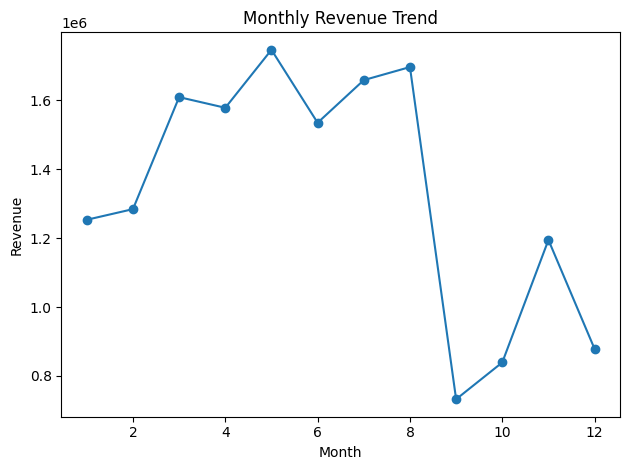

In [36]:
df["order_purchase_timestamp"] = pd.to_datetime(df["order_purchase_timestamp"])
df["month"] = df["order_purchase_timestamp"].dt.month

monthly_revenue = df.groupby("month")["payment_value"].sum()

monthly_revenue.plot(kind="line", marker="o")

plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")

plt.tight_layout()
plt.show()

💡 Key Business Insight:
Revenue fluctuates across months. Some months show peak sales indicating seasonal demand.

### Customer Segmentation (CLV)

Customers are segmented into Low, Medium, and VIP based on total spending.
VIP customers generate the highest revenue despite being fewer.

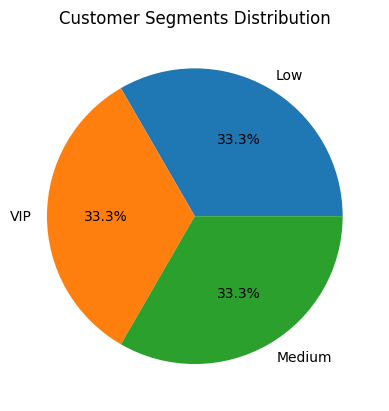

In [37]:
clv = df.groupby("customer_id")["payment_value"].sum().reset_index()
clv.columns = ["customer_id", "total_spent"]

clv = clv.sort_values(by="total_spent", ascending=False)

clv["segment"] = pd.qcut(clv["total_spent"], q=3, labels=["Low", "Medium", "VIP"])

clv["segment"].value_counts().plot(kind="pie", autopct="%1.1f%%")

plt.title("Customer Segments Distribution")
plt.show()

💡 Key Business Insight:
VIP customers contribute the highest revenue despite being fewer in number. 
Focusing on high-value customers can significantly increase business profit.

## 🏁 Final Conclusion

- Delivered orders drive most of the revenue  
- Top cities are key business areas  
- Revenue varies across months  
- VIP customers generate the highest value
- This project helps businesses make data-driven decisions to increase revenue and customer retention.

## 🚀 Business Recommendations
- Improve delivery success rate to increase completed transactions
- Focus marketing efforts on high-value (VIP) customers
- Expand business in top-performing cities
- Use seasonal trends for better campaign planning
